In [189]:
import random
import sklearn
import sklearn.datasets 
import sklearn.svm as svm
import numpy as np
from matplotlib import pyplot as plt
import sys
import math


# Tell matplotlib to show the plots within the notebook.
%matplotlib inline

Welcome to the second part of Assignment 1. Please remember that there is another Notebook together with this :) 

In this Notebook we will start by downloading a small digits dataset and visualizing some samples. Afterwards, we will learn how to split our data to train-validation-test splits in order to train a linear classifier. Don't worry, we will use existing library for training the classifier. Our focus is mainly on splitting the data and being able to process the output of a classifier. 

You will learn how to convert raw outputs to predictions and probability distributions. We will also do a very small hyper-parameter tuning over our validation set. 

In [190]:
digits = sklearn.datasets.load_digits()

Visualize some images! 

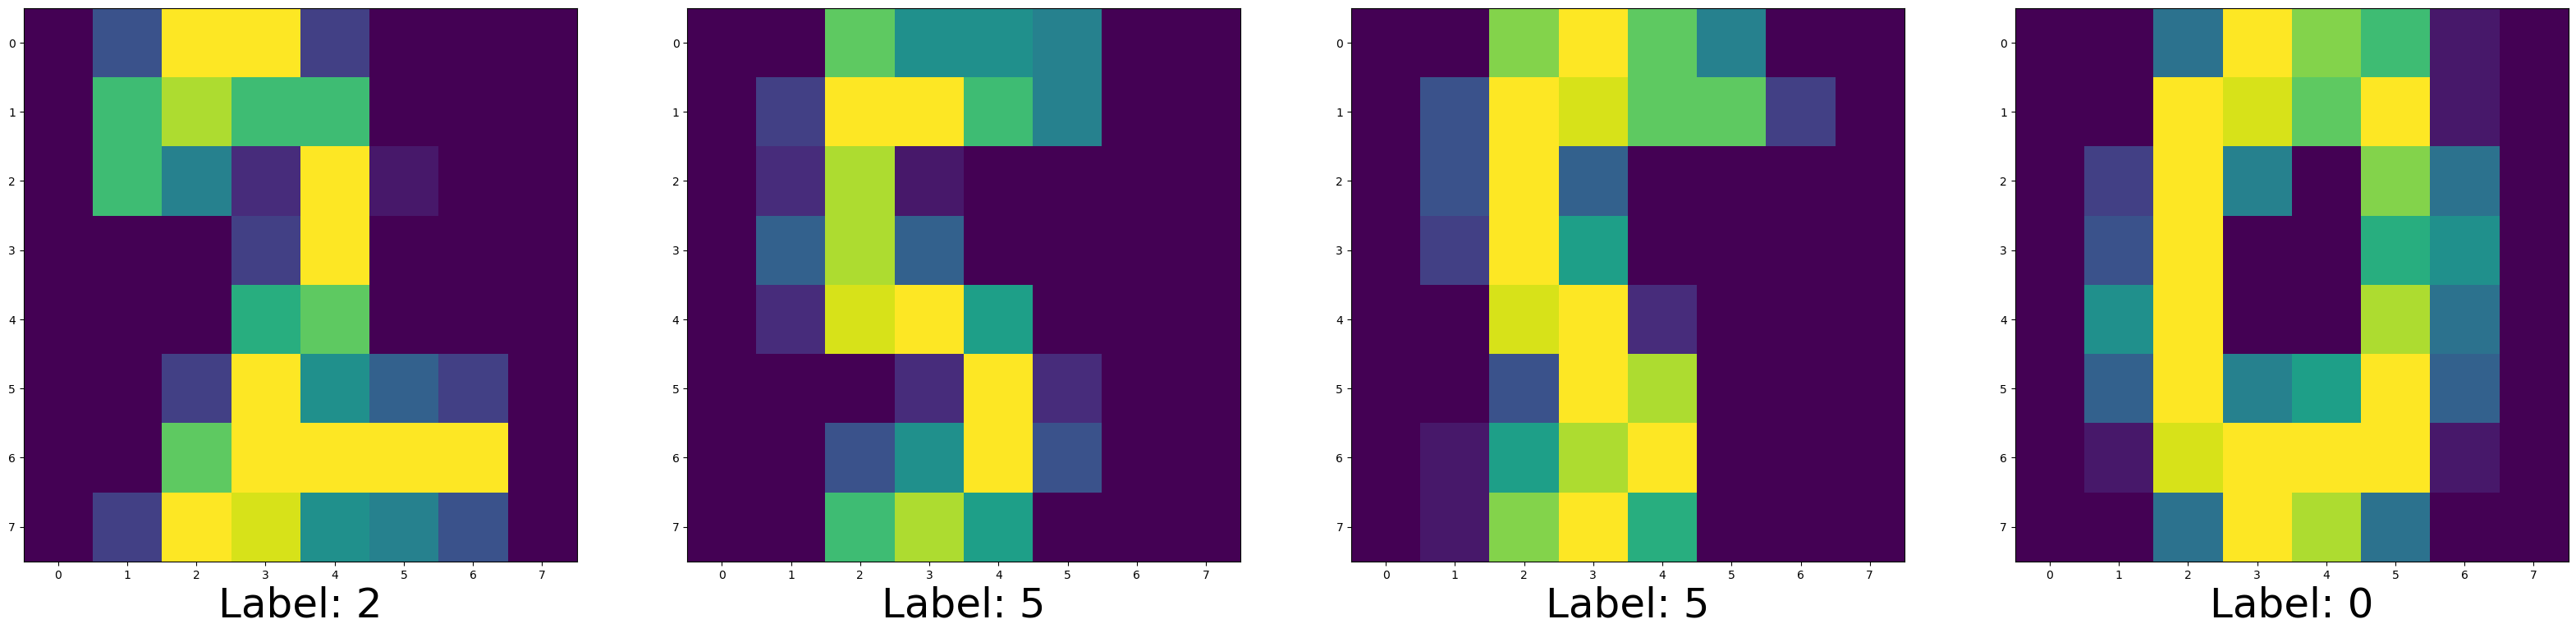

In [191]:
n = 4
random_indices = [random.randint(0, len(digits.images)) for i in range(n)]

fig, axes = plt.subplots(1, n, figsize=(40*1, 40*n))

for _col, sample_idx in enumerate(random_indices):
    img, lbl = digits.images[sample_idx], digits.target[sample_idx]
    axes[_col].imshow(img)
    axes[_col].set_xlabel(f"Label: {lbl}", fontsize=36) 

plt.show()

In [192]:
def train_test_split(data, target, fraction):
    ################################
    # 1. Shuffle the data and targets
    # 2. Split it based on the fraction
    # 3. Return (train_1, target_1, train_2, target_2of two splits
	# You `cannot` use train_test_split function provided by some library.
	# You are however welcome to look into their source code to see how one does this if it helps.
    #######################################
     
    shuffled_data, shuffled_target = sequence_shuffle(data, target)
    
    data_train = shuffled_data[:int(len(shuffled_data)* fraction)]
    data_test = shuffled_data[int(len(shuffled_data)* fraction):]
    
    target_train = shuffled_target[:int(len(shuffled_target)* fraction)]
    target_test = shuffled_target[int(len(shuffled_target)* fraction):]

    target_train = target_train.reshape((len(target_train)))  
    target_test = target_test.reshape((len(target_test)))  
    
    return data_train, target_train, data_test, target_test

def sequence_shuffle(sequence1, sequence2):
    for i in range(len(sequence1) - 2):
        random_index1 = random.randint(0, len(sequence1) - 1)
        random_index2 = random.randint(0, len(sequence2) - 1)
        
        temp = sequence1[random_index1]
        sequence1[random_index1] = sequence1[random_index2]
        sequence1[random_index2] = temp
        
        temp2 = sequence2[random_index1]
        sequence2[random_index1] = sequence2[random_index2]
        sequence2[random_index2] = temp2  
        
    return sequence1, sequence2

        

In [193]:
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

n_target = len(digits.target)
target = digits.target.reshape((n_target, -1))

In [194]:
# Split data into 50% train and 50% test subsets
X_trainval, y_trainval, X_test, y_test = \
    train_test_split( 
        # First separate the test samples!
        # Side-note: In a real benchmark people often use the same official test-set so that they can
        # compare their numbers to each other. In this assignment however we simply create our own
        # randomly selectd test set from the data.
        data, target, 0.5
    )

# Now Split the TRAIN data into 80% train and 20% validation subsets
X_train, y_train, X_val, y_val = \
    train_test_split( 
        #Now separate the cross-validation samples!
        X_trainval, y_trainval, 0.8
)

In [195]:
print(f"{X_train.shape=} {y_train.shape=}")
print(f"{X_val.shape=} {y_val.shape=}")
print(f"{X_test.shape=} {y_test.shape=}")


X_train.shape=(718, 64) y_train.shape=(718,)
X_val.shape=(180, 64) y_val.shape=(180,)
X_test.shape=(899, 64) y_test.shape=(899,)


In [196]:
# Create a classifier: a support vector classifier
clf = svm.SVC(gamma=0.001)

# Now fit the classifier
clf.fit(X_train, y_train)

# Predict the value of the digit on the val subset
output = clf.decision_function(X_val)

print(f"Model output has shape {output.shape}")


################################
# Use the (N, 10) outputs to get (N,) predictions (i.e class labels)
preds = []
for i in range(len(output)):
    max = -sys.maxsize - 1
    max_index = 0
    for j in range(len(output[i])):
        if (output[i][j] > max):
            max = output[i][j]
            max_index = j
    preds.append(max_index)
    
print(f"Predictions: {preds}")
########################################

Model output has shape (180, 10)
Predictions: [2, 7, 3, 6, 3, 6, 6, 8, 1, 0, 2, 0, 1, 1, 9, 4, 2, 4, 7, 3, 9, 9, 7, 8, 4, 9, 9, 1, 4, 9, 3, 6, 0, 3, 6, 4, 4, 7, 6, 1, 6, 8, 2, 4, 0, 0, 2, 5, 7, 3, 0, 8, 5, 3, 0, 7, 5, 0, 1, 9, 7, 8, 2, 7, 9, 5, 6, 2, 6, 9, 4, 3, 0, 1, 5, 8, 0, 7, 6, 6, 9, 6, 0, 3, 6, 5, 3, 8, 1, 4, 5, 6, 6, 5, 5, 8, 8, 7, 5, 6, 8, 0, 5, 6, 3, 1, 4, 7, 5, 6, 7, 1, 2, 6, 6, 4, 9, 7, 5, 0, 0, 1, 6, 5, 6, 5, 8, 7, 6, 6, 0, 5, 7, 1, 7, 2, 0, 0, 3, 1, 6, 1, 9, 3, 2, 4, 5, 1, 4, 3, 6, 1, 8, 5, 6, 8, 3, 3, 3, 6, 9, 3, 6, 9, 7, 0, 1, 5, 9, 8, 7, 8, 0, 0, 6, 5, 5, 6, 0, 6]


In [197]:
def accuracy_top1(predictions, targets):
    ################################
    # Return the mean accuracy (range from [0, 100])
    top1_acc = 0
    match_count = 0
    prediction_count = len(targets)
    
    for i in range(prediction_count):
        if (predictions[i] == targets[i]):
            match_count = match_count + 1
            
    top1_acc = (match_count / prediction_count) * 100
    
    return top1_acc 
    ########################################

In [198]:
print(f"Cross-validation accuracy is {accuracy_top1(preds, y_val):0.3f}")

Cross-validation accuracy is 42.222


Go back to the previous cell and try different gamma values [0.1 0.01 0.001 0.0001 0.00001] for the classifier configuration and report results for each over the `val` set. Simply replace the written 0.1 value.


Please write down your tested values and results here. Which gamma value worked best on the val set?

| Tested Gamma Values | Test Results (Cross-validation accuracy) |
| :- | -: |
| 0.1 | 12.778 |
| 0.01 | 15.000 |
| 0.001 | 36.658 |
| 0.0001 | 35.556 |
| 0.00001 | 10.000 |




In [199]:
# Now insert your best gamma value and train the model again.
best_gamma_value = 0.001

clf = svm.SVC(gamma=best_gamma_value)
# Learn the digits on the train subset
clf.fit(X_train, y_train)

# Predict the value of the digit on the test subset
output = clf.decision_function(X_test)

################################
# Use the (N, 10) outputs to get (N,) predictions (i.e class labels)

preds = []
for i in range(len(output)):
    max = -sys.maxsize - 1
    max_index = 0
    for j in range(len(output[i])):
        if (output[i][j] > max):
            max = output[i][j]
            max_index = j
    preds.append(max_index)

print(f"Predictions: {preds}")
########################################

Predictions: [1, 6, 7, 7, 0, 3, 9, 1, 1, 8, 6, 1, 7, 1, 1, 9, 5, 0, 1, 2, 6, 6, 6, 6, 0, 8, 1, 0, 3, 2, 9, 4, 2, 6, 6, 8, 9, 0, 3, 1, 4, 6, 5, 0, 6, 5, 3, 8, 9, 8, 6, 8, 1, 9, 6, 2, 7, 8, 9, 2, 3, 7, 6, 1, 3, 2, 4, 9, 4, 6, 6, 5, 4, 6, 3, 3, 0, 6, 4, 2, 8, 7, 0, 3, 1, 1, 6, 7, 2, 1, 4, 6, 3, 1, 3, 9, 1, 7, 3, 4, 2, 5, 0, 6, 4, 9, 7, 5, 9, 6, 3, 1, 2, 4, 2, 0, 4, 3, 2, 6, 9, 1, 9, 4, 4, 4, 3, 3, 8, 9, 3, 0, 6, 2, 7, 4, 7, 6, 7, 6, 0, 0, 1, 2, 8, 5, 4, 9, 1, 8, 3, 3, 6, 2, 3, 4, 5, 5, 2, 8, 1, 7, 2, 5, 5, 6, 2, 8, 7, 1, 8, 8, 1, 1, 6, 7, 3, 1, 7, 0, 0, 7, 6, 3, 0, 1, 4, 1, 3, 4, 7, 3, 3, 1, 6, 2, 6, 4, 1, 3, 4, 0, 0, 2, 1, 5, 7, 2, 5, 6, 7, 5, 3, 8, 1, 7, 4, 7, 3, 1, 2, 6, 3, 7, 1, 8, 6, 8, 8, 5, 8, 6, 9, 6, 2, 6, 7, 0, 8, 4, 2, 7, 2, 8, 2, 2, 5, 4, 0, 5, 7, 1, 5, 2, 9, 0, 5, 3, 7, 1, 4, 5, 6, 2, 5, 0, 5, 1, 7, 0, 2, 5, 1, 2, 7, 8, 7, 8, 5, 3, 1, 7, 3, 4, 1, 6, 7, 8, 2, 0, 0, 1, 1, 4, 5, 7, 8, 5, 2, 9, 4, 3, 9, 1, 9, 3, 5, 0, 4, 6, 4, 7, 1, 2, 4, 1, 4, 9, 3, 3, 7, 3, 3, 7, 6, 6, 0, 4, 2,

In [200]:
print(f"Final test accuracy is {accuracy_top1(preds, y_test):0.3f}")

Final test accuracy is 91.546


In [201]:
def softmax(x):
    """
    Args       x: Numpy array of shape (N, num_classes) with real values
    Returns    Numpy array of shape (N, num_classes) with softmax probability scores
    """
    ################################
    # return per-sample softmax scores

    for i in range(len(x)):
        denominator = 0
        for j in range(len(x[i])):
            denominator = denominator + math.exp(x[i][j])
        
        for j in range(len(x[i])):
            x[i][j] = math.exp(x[i][j]) / denominator

    return x

    ########################################

################################
# Using the softmax function defined above, convert (N, 10) outputs 
#to (N,) Softmax probabilities for the predicted class

scores = []
output = softmax(output)
for i in range(len(output)):
    max = -sys.maxsize - 1
    max_index = 0
    for j in range(len(output[i])):
        if (output[i][j] > max):
            max = output[i][j]
            max_index = j
    scores.append(max_index)
    
print(f"Softmax scores: {scores}")
########################################


Softmax scores: [1, 6, 7, 7, 0, 3, 9, 1, 1, 8, 6, 1, 7, 1, 1, 9, 5, 0, 1, 2, 6, 6, 6, 6, 0, 8, 1, 0, 3, 2, 9, 4, 2, 6, 6, 8, 9, 0, 3, 1, 4, 6, 5, 0, 6, 5, 3, 8, 9, 8, 6, 8, 1, 9, 6, 2, 7, 8, 9, 2, 3, 7, 6, 1, 3, 2, 4, 9, 4, 6, 6, 5, 4, 6, 3, 3, 0, 6, 4, 2, 8, 7, 0, 3, 1, 1, 6, 7, 2, 1, 4, 6, 3, 1, 3, 9, 1, 7, 3, 4, 2, 5, 0, 6, 4, 9, 7, 5, 9, 6, 3, 1, 2, 4, 2, 0, 4, 3, 2, 6, 9, 1, 9, 4, 4, 4, 3, 3, 8, 9, 3, 0, 6, 2, 7, 4, 7, 6, 7, 6, 0, 0, 1, 2, 8, 5, 4, 9, 1, 8, 3, 3, 6, 2, 3, 4, 5, 5, 2, 8, 1, 7, 2, 5, 5, 6, 2, 8, 7, 1, 8, 8, 1, 1, 6, 7, 3, 1, 7, 0, 0, 7, 6, 3, 0, 1, 4, 1, 3, 4, 7, 3, 3, 1, 6, 2, 6, 4, 1, 3, 4, 0, 0, 2, 1, 5, 7, 2, 5, 6, 7, 5, 3, 8, 1, 7, 4, 7, 3, 1, 2, 6, 3, 7, 1, 8, 6, 8, 8, 5, 8, 6, 9, 6, 2, 6, 7, 0, 8, 4, 2, 7, 2, 8, 2, 2, 5, 4, 0, 5, 7, 1, 5, 2, 9, 0, 5, 3, 7, 1, 4, 5, 6, 2, 5, 0, 5, 1, 7, 0, 2, 5, 1, 2, 7, 8, 7, 8, 5, 3, 1, 7, 3, 4, 1, 6, 7, 8, 2, 0, 0, 1, 1, 4, 5, 7, 8, 5, 2, 9, 4, 3, 9, 1, 9, 3, 5, 0, 4, 6, 4, 7, 1, 2, 4, 1, 4, 9, 3, 3, 7, 3, 3, 7, 6, 6, 0, 4,

Visualize some of the test predictions!

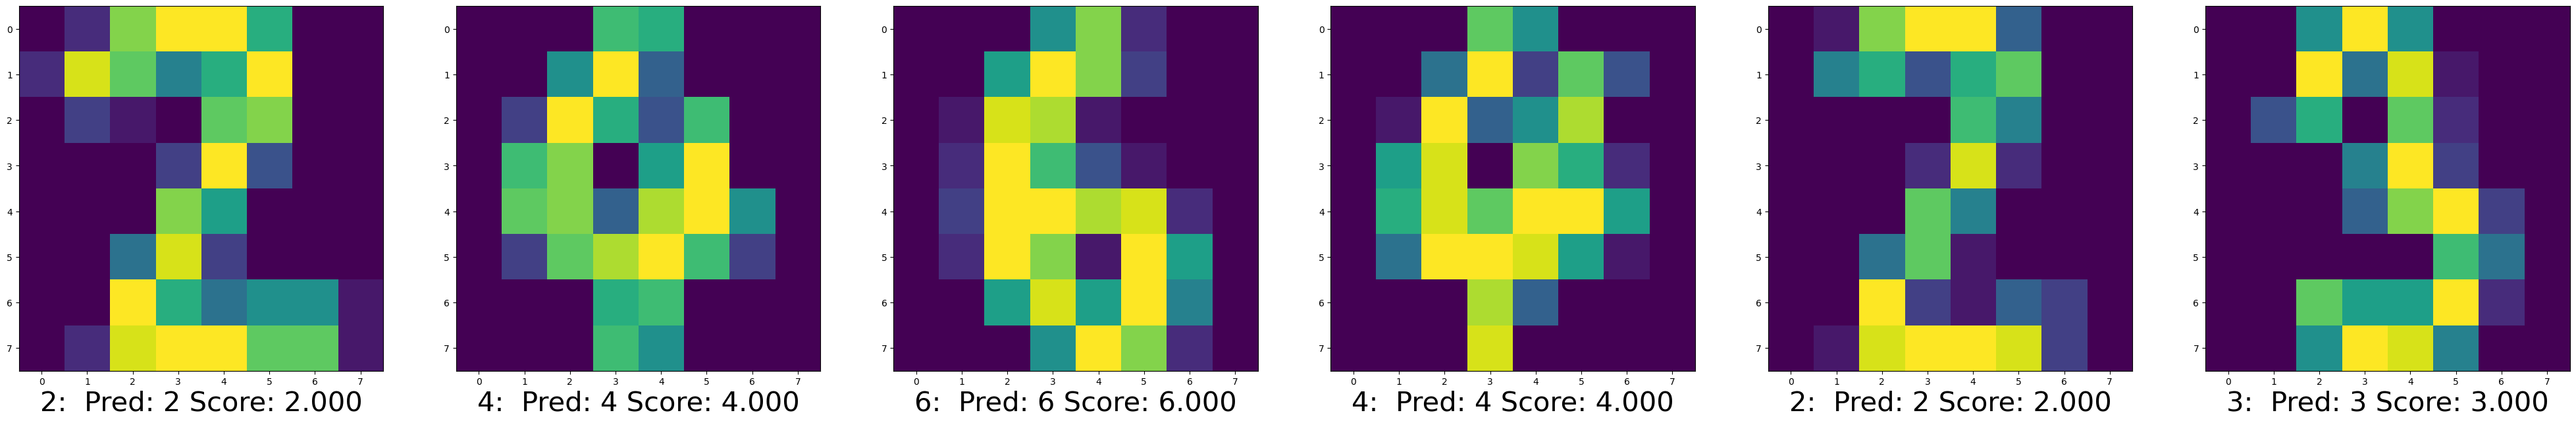

In [202]:
n = 6
random_indices = [random.randint(0, len(X_test)) for i in range(n)]
fig, axes = plt.subplots(1, n, figsize=(50*1, 50*n))


for _col, sample_idx in enumerate(random_indices):
    img = X_test[sample_idx].reshape((8, 8))
    lbl = y_test[sample_idx]

    axes[_col].imshow(img)
    axes[_col].set_xlabel(
        f"{lbl}:  Pred: {preds[sample_idx]} Score: {scores[sample_idx]:0.3f}",
        fontsize=30
    )

plt.show()